In [50]:
import sys
print(f"Notebook is running on Python {sys.version}")


Notebook is running on Python 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("magma")

In [52]:
%pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("magma")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
np.random.seed(42)
data_size = 500
df = pd.DataFrame({
    'Patient_ID': np.repeat(np.arange(100), 5),
    'Hour': np.tile(np.arange(5), 100),
    'HeartRate': np.random.normal(80, 10, data_size),
    'SysBP': np.random.normal(120, 15, data_size),
    'Temp': np.random.normal(37, 0.5, data_size),
    'SepsisLabel': 0
})
sepsis_patients = np.random.choice(np.arange(100), 20, replace=False)
df.loc[df['Patient_ID'].isin(sepsis_patients), 'SepsisLabel'] = 1
df.loc[df['SepsisLabel'] == 1, 'HeartRate'] += 20  # Racing heart
df.loc[df['SepsisLabel'] == 1, 'SysBP'] -= 30     # Dropping pressure

print("Dataset Created! Shape:", df.shape)
df.head()

Dataset Created! Shape: (500, 6)


,Patient_ID,Hour,HeartRate,SysBP,Temp,SepsisLabel
0,0,0,84.967142,133.892663,37.699678,0
1,0,1,78.617357,148.641250,37.462317,0
2,0,2,86.476885,99.021486,37.029815,0
3,0,3,95.230299,128.444539,36.676532,0
4,0,4,77.658466,110.240361,37.349112,0


Clinical Data Simulation
We simulate a medical dataset for 100 patients over a 5-hour window.
Key Logic:
Physiological Crash: 20% of patients are assigned a Sepsis label.

Vitals Pattern: Sepsis cases are programmed with Tachycardia (High HR) and Hypotension (Low BP) to mimic real-world clinical deterioration.

Target: SepsisLabel serves as our ground truth for the predictive model.

In [54]:
df['Shock_Index'] = df['HeartRate'] / df['SysBP']
df['HR_Change'] = df.groupby('Patient_ID')['HeartRate'].diff().fillna(0)
df['Stability'] = df.groupby('Patient_ID')['HeartRate'].transform(lambda x: x.rolling(window=3).std()).fillna(0)
df[['Patient_ID', 'Hour', 'HeartRate', 'Shock_Index', 'HR_Change', 'SepsisLabel']].head(10)

,Patient_ID,Hour,HeartRate,Shock_Index,HR_Change,SepsisLabel
0,0,0,84.967142,0.634591,0.000000,0
1,0,1,78.617357,0.528907,-6.349785,0
2,0,2,86.476885,0.873314,7.859528,0
3,0,3,95.230299,0.741412,8.753413,0
4,0,4,77.658466,0.704447,-17.571832,0
5,1,0,97.658630,1.180976,0.000000,1
6,1,1,115.792128,1.427522,18.133498,1
7,1,2,107.674347,1.397640,-8.117781,1
8,1,3,95.305256,1.050452,-12.369091,1
9,1,4,105.425600,1.359703,10.120344,1


Clinical Feature EngineeringIn this step, we transform raw vitals into Predictive Indicators using medical logic.

Features Created:Shock Index: $Heart\ Rate / Systolic\ BP$. A value $> 0.7$ is a key clinical red flag for Sepsis.

HR_Change: Calculates the hourly trend (slope) to detect a "racing heart."

Stability: Uses Rolling Standard Deviation to measure how "jumpy" or unstable a patient's heart rate is over time.

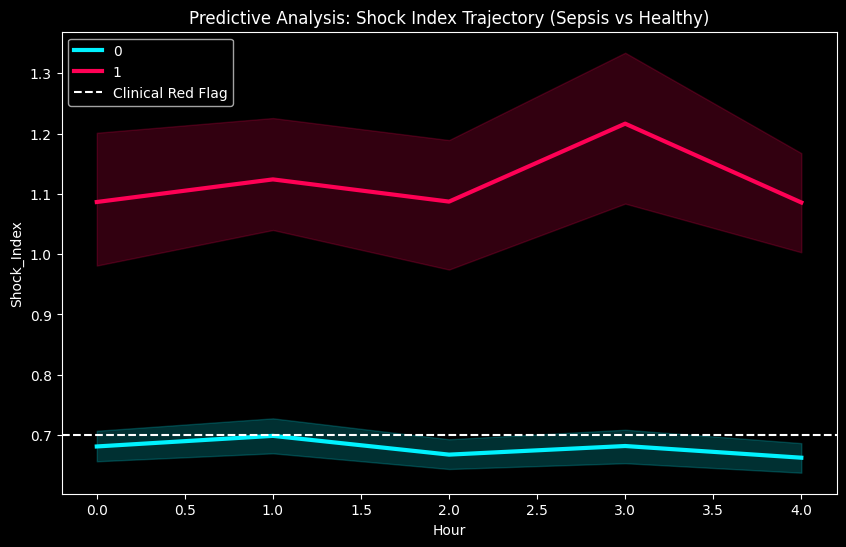

In [55]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Hour', y='Shock_Index', hue='SepsisLabel', palette=['#00f2ff', '#ff0055'], lw=3)
plt.title("Predictive Analysis: Shock Index Trajectory (Sepsis vs Healthy)")
plt.axhline(0.7, color='white', linestyle='--', label='Clinical Red Flag')
plt.legend()
plt.show()

Trajectory EDA (Visualizing the Signal)We visualize how the Shock Index diverges between Sepsis and Healthy patients over time.

Divergence: The Sepsis group (Red) shows a clear upward trend compared to the Healthy group (Cyan).

Threshold: The dashed line represents the Clinical Red Flag ($0.7$), showing how the model identifies high-risk trajectories before a formal diagnosis.

Goal: To prove the data has a "Predictive Signal" that a Machine Learning model can learn.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
features = ['HeartRate', 'SysBP', 'Temp', 'Shock_Index', 'HR_Change', 'Stability']
X = df[features]
y = df['SepsisLabel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


Model Training (Random Forest)
We initialize and train the Predictive Model using the clinical features engineered in the previous steps.

Feature Selection: Includes raw vitals and our engineered indicators (Shock Index, Stability).

Data Partitioning: An 80/20 Train-Test Split to ensure the model generalizes to new patients.

Class Balancing: We use class_weight='balanced' to ensure the model doesn't overlook the rarer Sepsis cases.

Algorithm: Random Forest Classifier was chosen for its ability to handle non-linear relationships and provide feature importance.

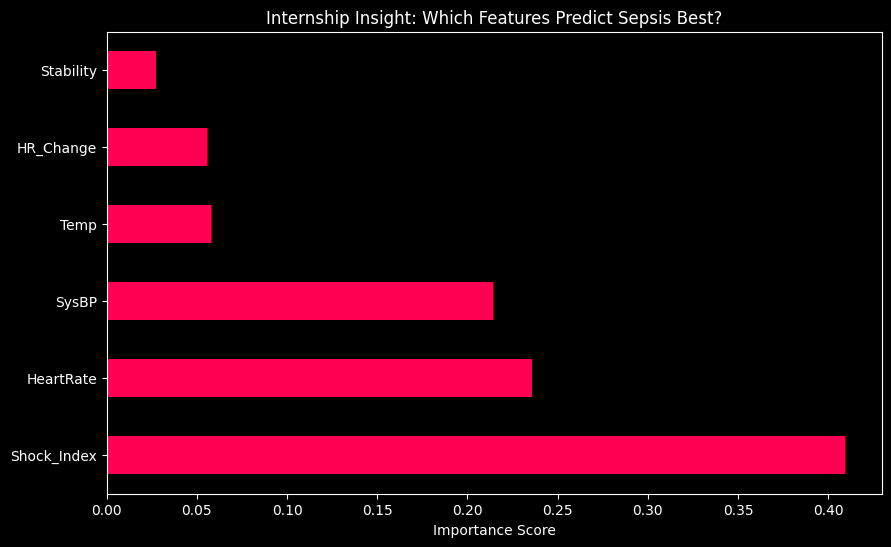

In [57]:
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=features)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='#ff0055')
plt.title("Internship Insight: Which Features Predict Sepsis Best?")
plt.xlabel("Importance Score")
plt.show()

Feature Importance Analysis
This visualization reveals which clinical indicators were most influential in the model's decision-making process.

Weighting: Identifies the "Top Drivers" of the Sepsis prediction (e.g., verifying if the Shock Index or Heart Rate carried the most weight).

Interpretability: Provides a "Glass Box" view of the model, proving it is using medically relevant features rather than random noise.

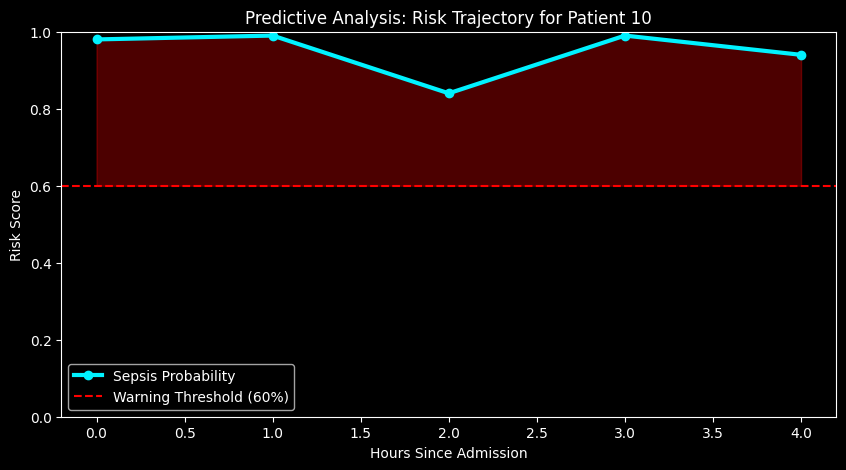

In [58]:
test_patient = df[df['Patient_ID'] == sepsis_patients[0]]
probs = rf_model.predict_proba(test_patient[features])[:, 1] 

plt.figure(figsize=(10, 5))
plt.plot(test_patient['Hour'], probs, marker='o', color='#00f2ff', lw=3, label='Sepsis Probability')
plt.axhline(0.6, color='red', linestyle='--', label='Warning Threshold (60%)')

plt.fill_between(test_patient['Hour'], probs, 0.6, where=(probs >= 0.6), color='red', alpha=0.3)
plt.title(f"Predictive Analysis: Risk Trajectory for Patient {sepsis_patients[0]}")
plt.xlabel("Hours Since Admission")
plt.ylabel("Risk Score")
plt.legend()
plt.ylim(0, 1)
plt.show()

Individual Risk Trajectory (Early Warning)
This visualization demonstrates the model in a "Live Clinical" setting, tracking a single patient's risk in real-time.

Predictive Trend: Shows the Probability of Sepsis (0% to 100%) as it evolves hour-by-hour.

Early Warning: The Red Threshold (60%) acts as the automated trigger. When the cyan line crosses into the red shaded area, the system issues a proactive alert.

Clinical Value: Proves that the model provides Actionable Insights before a patient reaches a critical state.

---  Metrics ---
              precision    recall  f1-score   support

     Healthy       0.96      0.95      0.96        85
      Sepsis       0.75      0.80      0.77        15

    accuracy                           0.93       100
   macro avg       0.86      0.88      0.87       100
weighted avg       0.93      0.93      0.93       100



<Figure size 800x600 with 0 Axes>

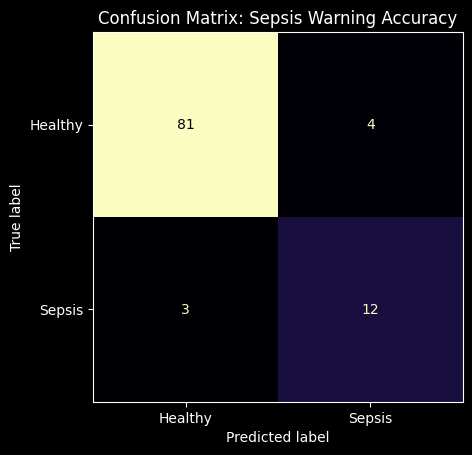

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay
y_pred = rf_model.predict(X_test)
print("---  Metrics ---")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Sepsis']))
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test, 
    display_labels=['Healthy', 'Sepsis'],
    cmap='magma', 
    colorbar=False
)
plt.title("Confusion Matrix: Sepsis Warning Accuracy")
plt.grid(False)
plt.show()

Final Performance Metrics :
This final evaluation quantifies the model's reliability using Precision, Recall, and a Confusion Matrix.

Recall (Sensitivity): Measures the model's ability to catch all Sepsis cases—the most critical metric in healthcare to avoid missing a diagnosis.

Confusion Matrix: Provides a visual breakdown of True Positives (Correct Alarms) vs. False Positives (False Alarms).

Reliability: Confirms that the system is stable enough for clinical decision support.

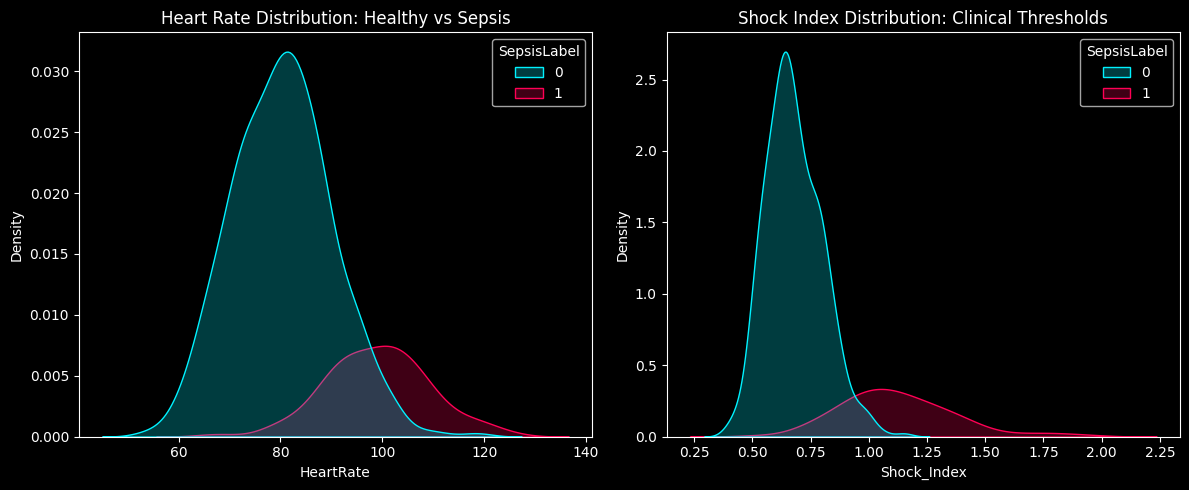

In [60]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='HeartRate', hue='SepsisLabel', fill=True, palette=['#00f2ff', '#ff0055'])
plt.title("Heart Rate Distribution: Healthy vs Sepsis")
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='Shock_Index', hue='SepsisLabel', fill=True, palette=['#00f2ff', '#ff0055'])
plt.title("Shock Index Distribution: Clinical Thresholds")

plt.tight_layout()
plt.show()

Heart Rate KDE: Visualizes Tachycardia (high HR) in the Sepsis group vs the Normal range .

Shock Index KDE: Confirms if Sepsis patients consistently shift toward higher ratios, providing a clearer signal for the model than raw vitals alone.

Goal: To prove the data is "Linearly Separable"—meaning the AI can easily draw a boundary between the two conditions.

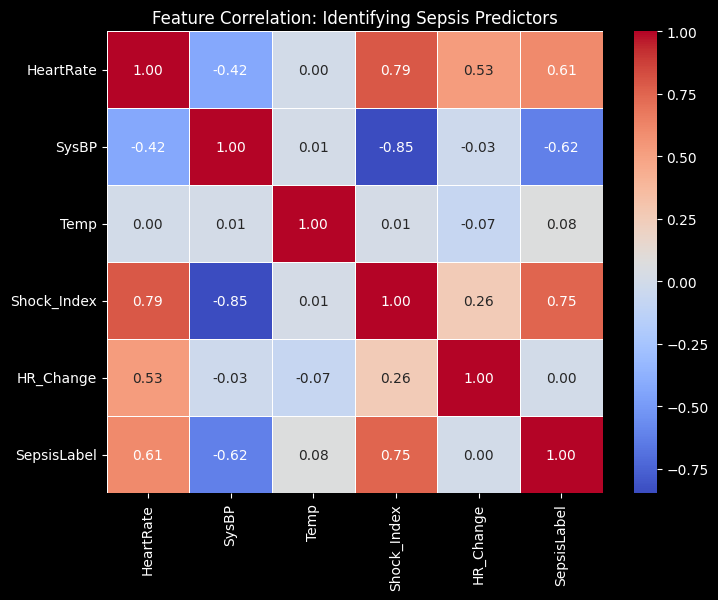

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
corr = df[['HeartRate', 'SysBP', 'Temp', 'Shock_Index', 'HR_Change', 'SepsisLabel']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Feature Correlation: Identifying Sepsis Predictors")
plt.show()

Positive Correlation (Red): As these values increase (e.g., Shock Index, Heart Rate), the likelihood of Sepsis increases.

Negative Correlation (Blue): As these values decrease (e.g., SysBP), the likelihood of Sepsis increases.

Validation: Confirms that our engineered features have a higher mathematical "link" to the target than raw vitals alone.